In [8]:
import glob
import shutil
import subprocess
import traceback
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyBigWig
import seaborn as sns
import xarray as xr
import zarr
from tqdm import tqdm

In [9]:
def compute_bam_coverage(bam_file, output_file, binsize=1, norm_method="raw"):
    """
    Use BamNado to generate BAM coverage per contig.

    Parameters:
        bam_file (str): Path to the input BAM file.
        output_file (str): Path to the output BigWig file.
        binsize (int): Bin size for coverage calculation.
        norm_method (str): Normalization method (default: "raw").

    Returns:
        dict: Coverage data as a dictionary with chromosome names as keys and coverage arrays as values.
    """

    # Construct the BamNado command
    bamnado_path = "/Users/catherine/work/project/BamNado/target/release/bamnado"
    command = [
        bamnado_path,
        "bam-coverage",
        "--bam",
        str(bam_file),
        "--output",
        str(output_file),
        "--bin-size",
        str(binsize),
        "--norm-method",
        norm_method,
    ]

    subprocess.run(command, check=True, text=True, capture_output=True)

### Step 1: Add coverage data

In [10]:
# Store coverage data for each sample and chromosome separately
coverage_dict = {}

# Process BAM files
data_path = Path("/Users/catherine/work/project/QuantNado/data/multiomics_run0/seqnado_output/")
bam_path = f"{data_path}/**/*.bam"
bam_files = sorted(glob.glob(bam_path, recursive=True))

for bam_file in tqdm(bam_files, desc="Processing BAM files"):
    bam_name = Path(bam_file).stem
    assay_name = bam_file.split("/")[-3]  # Extract assay name from the file path
    bw_dir = Path("examples/bigwigs")
    bw_dir.mkdir(exist_ok=True)
    bw_file = Path(f"{bw_dir}/{bam_name}_coverage.bw")

    try:
        # Compute BAM coverage
        compute_bam_coverage(bam_file, bw_file)

        # Read coverage data from BigWig
        bw = pyBigWig.open(str(bw_file))

        # Process each chromosome separately
        for chrom in bw.chroms():
            chrom_length = bw.chroms(chrom)
            # Get actual coverage values - this returns a list
            values_list = bw.values(chrom, 0, chrom_length)

            # Convert to numpy array immediately
            values = np.array(values_list, dtype=float)

            # Create key for this sample-chromosome combination
            key = (assay_name, bam_name, chrom)

            # Store coverage values with minimal coordinates
            # We'll add metadata later to avoid conflicts
            coverage_dict[key] = {
                "values": values,
                "sample": bam_name,
                "assay": assay_name,
                "chrom": chrom,
            }

        bw.close()

    except Exception as e:

        print(f"Error processing {bam_file}: {e}")
        traceback.print_exc()


Processing BAM files: 100%|██████████| 4/4 [00:08<00:00,  2.19s/it]


In [11]:
# Get all unique samples and chromosomes
all_samples = sorted(set(data["sample"] for data in coverage_dict.values()))
all_chroms = sorted(set(data["chrom"] for data in coverage_dict.values()))

# Create separate datasets for each chromosome since they have different lengths
datasets_by_chrom = {}

for chrom in all_chroms:
    # Get all samples that have this chromosome
    chrom_entries = [
        (key, data) for key, data in coverage_dict.items() if data["chrom"] == chrom
    ]

    if not chrom_entries:
        continue

    # Extract sample names, assays, and values
    samples = [data["sample"] for key, data in chrom_entries]
    assays = [data["assay"] for key, data in chrom_entries]
    values_list = [data["values"] for key, data in chrom_entries]

    # Get the position length for this chromosome
    position_length = len(values_list[0])

    # Stack all samples into a 2D array (samples × positions)
    stacked_values = np.stack(values_list, axis=0)

    # Create a Dataset for this chromosome with sample-specific data variables
    chrom_ds = xr.Dataset()

    for i, (sample, assay, values) in enumerate(zip(samples, assays, values_list)):
        var_name = f"{sample}"  # Use sample name as variable name
        chrom_ds[var_name] = xr.DataArray(
            values,
            dims=["position"],
            coords={"position": np.arange(position_length)},
            attrs={"assay": assay, "chromosome": chrom},
        )

    datasets_by_chrom[chrom] = chrom_ds

# For easy access, let's also create a reference
dataset = datasets_by_chrom

### Save the dataset to Zarr

In [15]:
# Save all chromosomes to a single Zarr store using groups
zarr_path = "examples/dataset.zarr"

# Remove old zarr if it exists
if Path(zarr_path).exists():
    shutil.rmtree(zarr_path)

# Create the root Zarr group
root = zarr.open_group(zarr_path, mode='w')

# Save each chromosome as a separate group
for chrom, ds in dataset.items():
    print(f"Saving {chrom}...")
    # Convert to zarr and save in the group
    ds.to_zarr(root.store, group=chrom, mode='a')

Saving AmpR...
Saving Cas9_3p...
Saving Cas9_5p...
Saving chr21...
Saving dm6_chr2L...


### Plot?

RUNX1 chr21:35,022,950-35,067,913

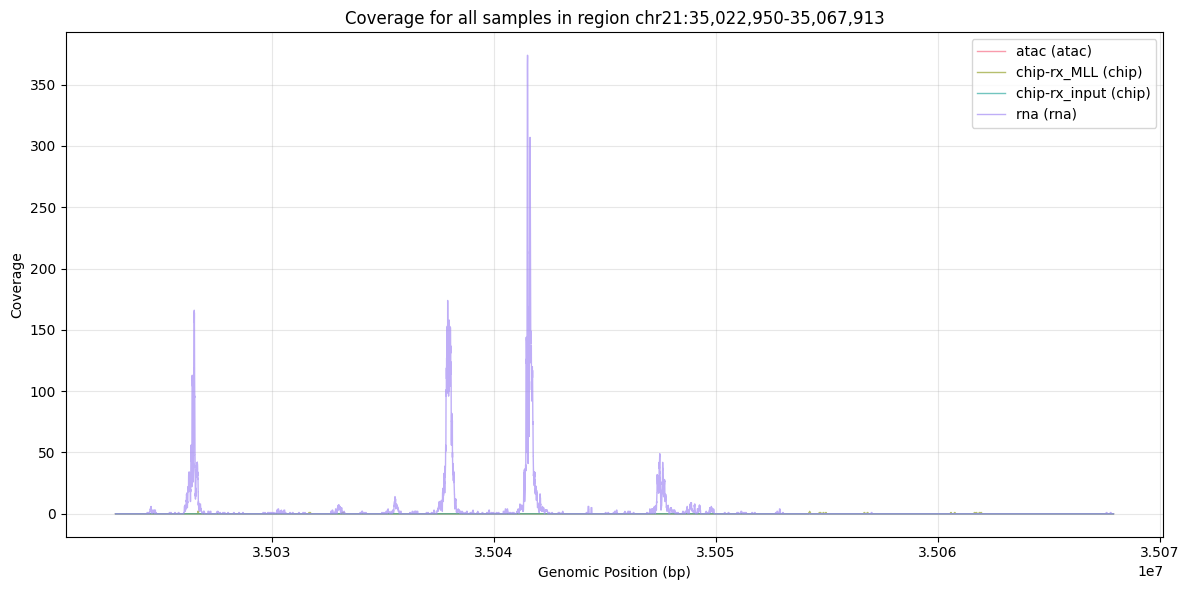

In [16]:
# Select chr21 dataset and extract region of interest
region_contig = "chr21"
start = 35022950
end = 35067913

chr21_ds = dataset[region_contig]

# Get the region
region_data = chr21_ds.sel(position=slice(start, end))

samples = list(region_data.data_vars.keys())
colours = sns.color_palette("husl", len(samples))
col_dict = dict(zip(samples, colours))

plt.figure(figsize=(12, 6))

for sample in samples:
    y_values = region_data[sample].values
    x_values = region_data["position"].values
    assay = region_data[sample].attrs.get("assay", sample)
    plt.plot(
        x_values,
        y_values,
        label=f"{sample} ({assay})",
        color=col_dict[sample],
        alpha=0.7,
        linewidth=1,
    )

plt.xlabel("Genomic Position (bp)")
plt.ylabel("Coverage")
plt.title(f"Coverage for all samples in region {region_contig}:{start:,}-{end:,}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
